# Appendix: predicting delivery time at order time

Notebooks 01 and 02 cover the main analysis. This one tests whether delivery time
can be predicted from order-time data, and whether that beats a per-state median.

## 1. Data preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

clean = pd.read_parquet("../data/clean/clean.parquet")
print(clean.shape)

(96470, 36)


## 2. Time-based split

In [2]:
TRIM = 60
TARGET = 'delivery_days'

clean = clean.sort_values('order_purchase_timestamp').reset_index(drop=True)

split_point = int(len(clean) * 0.8)
val_point = int(split_point * 0.85)

train_full = clean.iloc[:split_point]
test = clean.iloc[split_point:]
val = train_full.iloc[val_point:]

In [3]:
print("Train full:", len(train_full))
print("Val:", len(val), "(no trim)")
print("Test:", len(test), "(no trim)")
print("Val from:", val['order_purchase_timestamp'].min())
print("Test from:", test['order_purchase_timestamp'].min())
print("Test until:", test['order_purchase_timestamp'].max())
print("Orders >= 60 days in test:", (test[TARGET] >= TRIM).sum())

Train full: 77176
Val: 11577 (no trim)
Test: 19294 (no trim)
Val from: 2018-04-06 11:17:17
Test from: 2018-05-26 18:18:03
Test until: 2018-08-29 15:00:37
Orders >= 60 days in test: 14


Time-based split on 96,470 orders: train 77,176 (until 2018-05-26), test 19,294
(late May–Aug 2018). Validation is the last 15% of train, 11,577 orders from April
to May. The 60-day trim is applied only where the model is fitted; validation and
test keep the full tail, the way production would see it. 14 orders in test take
60+ days and stay there. All decisions are made on validation. Test is used once,
at the end. Test covers the fastest period of the year, no winter months.

In [4]:
cat_cols = ['customer_state', 'seller_state', 'product_category_name']

train_core_raw = clean.iloc[:val_point]
train_core_idx = train_core_raw.index[train_core_raw[TARGET] < TRIM]

for col in cat_cols:
    cats = clean.loc[train_core_idx, col].astype('category').cat.categories
    codes = pd.Categorical(clean[col], categories=cats).codes.astype('float64')
    codes[codes == -1] = np.nan
    clean[col + '_code'] = codes

print("Unknown categories:", clean[[c + '_code' for c in cat_cols]].isnull().sum().sum())

Unknown categories: 13


In [5]:
clean['distance_missing'] = clean['distance_km'].isnull().astype(int)
print("Orders with no usable coordinates:", clean['distance_missing'].sum())

Orders with no usable coordinates: 477


Orders with no zip-code coordinates get the training median. Median distance is a strong
assumption for an unknown location, so whether a value was imputed is kept as its own
column rather than disappearing into the number.

In [6]:
num_fill = ['total_weight_g', 'total_volume_cm3',
            'max_length_cm', 'max_height_cm', 'max_width_cm', 'distance_km']

medians = clean.loc[train_core_idx, num_fill].median()
clean[num_fill] = clean[num_fill].fillna(medians)

print("NaN left:", clean[num_fill].isnull().sum().sum())

NaN left: 0


In [7]:
train_full = clean.iloc[:split_point]
test = clean.iloc[split_point:]
val = train_full.iloc[val_point:]

train_core = clean.loc[train_core_idx]
train_fit = train_full[train_full[TARGET] < TRIM]

print("Train core:", len(train_core))
print("Train fit:", len(train_fit))

Train core: 65328
Train fit: 76884


Preprocessing after the split: category codes and medians are fitted on train_core
only. Categories unseen in training become NaN, which HistGradientBoosting treats as
a missing category rather than as a value below all others.

## 3. Baselines on validation

In [8]:
def baselines(fit_df, eval_df):
    naive = fit_df[TARGET].mean()
    mae_naive = (eval_df[TARGET] - naive).abs().mean()

    state_med  = fit_df.groupby('customer_state')[TARGET].median()
    global_med = fit_df[TARGET].median()
    pred_state = eval_df['customer_state'].map(state_med).fillna(global_med)
    mae_state  = (eval_df[TARGET] - pred_state).abs().mean()

    mae_olist = (eval_df['estimated_days'] - eval_df[TARGET]).abs().mean()
    return mae_naive, mae_state, mae_olist

In [9]:
mae_naive_val, mae_state_val, mae_olist_val = baselines(train_core, val)
print(f"Naive mean (val): {mae_naive_val:.3f}")
print(f"Per-state median: {mae_state_val:.3f}")
print(f"Olist estimate (val): {mae_olist_val:.3f}")

Naive mean (val): 6.653
Per-state median: 4.879
Olist estimate (val): 13.258


Baselines on validation: naive mean 6.65, per-state median 4.88, Olist estimate 13.26.
The naive mean is inflated by seasonal drift between train and val. The per-state
median is the honest bar: geography carries most of the signal, and a single number
that ignores it is not a real competitor.

A per-state median at 4.88 already beats the first RandomForest at 5.27. Any model that
does not clear this line is not adding anything to a groupby.

## 4. RandomForest

In [10]:
FEATURES = ['purchase_month', 'purchase_day_of_week', 'purchase_year',
            'total_price', 'total_freight', 'quantity_items', 'same_state', 'total_weight_g',
            'total_volume_cm3', 'customer_state_code', 'seller_state_code', 'product_category_name_code']

print("Missing: ", [c for c in FEATURES if c not in clean.columns])

Missing:  []


RandomForest cannot accept NaN, so unknown categories are filled with -1 for this model
only. HistGradientBoosting takes the NaN version later and treats it as a missing
category rather than as a value below all others.

In [11]:
X_train = train_core[FEATURES].fillna(-1)
Y_train = train_core[TARGET]
X_val   = val[FEATURES].fillna(-1)
Y_val   = val[TARGET]

print(X_train.shape, X_val.shape)

(65328, 12) (11577, 12)


In [12]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [13]:
pred = model_rf.predict(X_val)

mae_model_rf = mean_absolute_error(Y_val, pred)
r2_model_rf = r2_score(Y_val, pred)

print("R2 score Random Forest: ", r2_model_rf)
print("MAE score Random Forest: ", mae_model_rf)
print("MAE naive (val): ", mae_naive_val)
print("MAE Olist (val): ", mae_olist_val)

R2 score Random Forest:  0.20145928361416554
MAE score Random Forest:  5.267079507664234
MAE naive (val):  6.653044326739396
MAE Olist (val):  13.257669385179426


## 5. Error analysis

In [14]:
errors_rf = (Y_val - pred).abs()
print(errors_rf.describe().round(2))
print("Errors > 15 days:", (errors_rf > 15).sum())

count    11577.00
mean         5.27
std          5.16
min          0.00
25%          2.00
50%          4.07
75%          7.08
max        125.34
Name: delivery_days, dtype: float64
Errors > 15 days: 410


RandomForest MAE 5.27, worse than the per-state median at 4.88. Median error 4.07,
75% within 7.08, but 410 orders (3.5%) miss by more than 15 days and the worst case
is 125. R2 is 0.20, but it squares the errors so the few 60+ day orders dominate it.
MAE stays the primary metric.

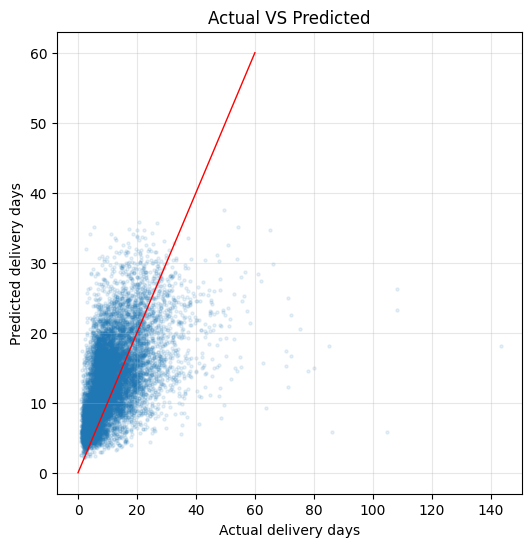

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_val, pred, alpha=0.1, s = 5)
plt.plot([0,60],[0,60], color='Red', linewidth = 1)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual VS Predicted")
plt.show()

Typical deliveries sit on the diagonal. Delays of 30+ days are predicted as 10–20 and model can't see them coming.

## 6. Feature importances

In [16]:
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(3))

same_state                    0.159
total_freight                 0.134
total_price                   0.118
total_volume_cm3              0.113
total_weight_g                0.105
customer_state_code           0.095
product_category_name_code    0.072
purchase_month                0.071
purchase_day_of_week          0.069
purchase_year                 0.030
seller_state_code             0.025
quantity_items                0.009
dtype: float64


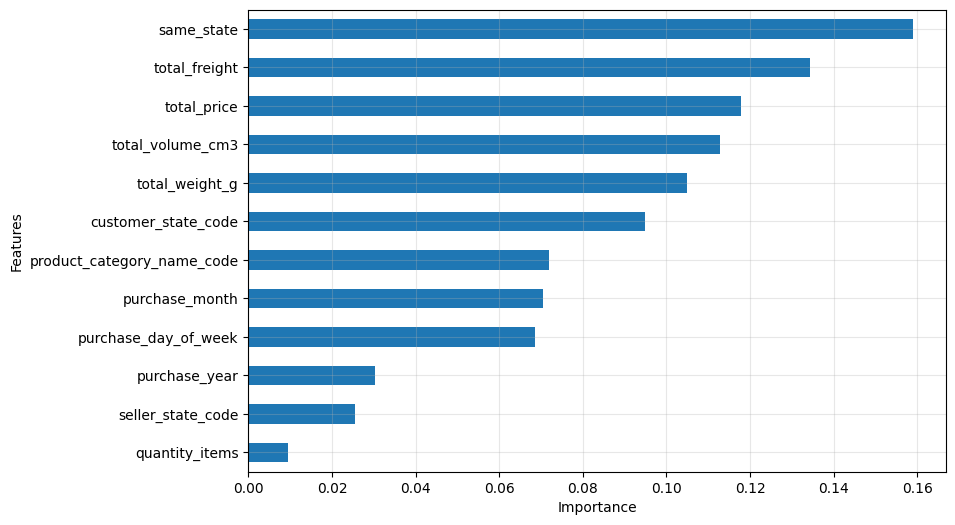

In [17]:
importances.sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 7. Feature ablation

Checking whether the weakest features by importance contribute to MAE or just add noise.

In [18]:
DROP = ['seller_state_code', 'purchase_year', 'quantity_items']

FEATURES_SLIM = [f for f in FEATURES if f not in DROP]

model_rf_slim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_slim.fit(train_core[FEATURES_SLIM].fillna(-1), Y_train)
pred_rf_slim = model_rf_slim.predict(val[FEATURES_SLIM].fillna(-1))

print("Features: ", len(FEATURES_SLIM))
print("MAE slim: ", round(mean_absolute_error(Y_val, pred_rf_slim), 3))
print("MAE full: ", round(mae_model_rf, 3))

Features:  9
MAE slim:  5.094
MAE full:  5.267


Dropped the three weakest features by importance. Validation MAE improved from 5.27 to 5.09.

purchase_year deserves a note beyond its low importance. Under a time-based split the test
period always falls in a year the model has never seen, and a tree cannot extrapolate past
its training range. It was never going to generalise; the ablation just confirms it.

RandomForest at 5.09 still loses to the per-state median at 4.88. A tree ensemble on
twelve features adds nothing over a groupby until the loss matches the metric.

## 8. HistGradientBoosting

In [19]:
HGB_PARAMS = dict(loss='absolute_error', random_state=42)

model_hgb = HistGradientBoostingRegressor(**HGB_PARAMS)
model_hgb.fit(train_core[FEATURES_SLIM], Y_train)
pred_hgb = model_hgb.predict(val[FEATURES_SLIM])

print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))
print("MAE RF slim: ", mean_absolute_error(Y_val, pred_rf_slim))

MAE HGB slim:  4.522614891288158
MAE RF slim:  5.0935267793610635


In [20]:
print("R2: ", r2_score(Y_val, pred_hgb))

errors_hgb = round((Y_val - pred_hgb).abs(), 3)
print("Errors > 15: ", (errors_hgb > 15).sum())

R2:  0.27458920699911293
Errors > 15:  448


HistGradientBoosting on the same 9 features with absolute_error loss: MAE 4.52 vs
5.09 RF. The largest single gain in the project, and most of it comes from the loss
matching the metric rather than from the model class.

Note the trade-off: HGB has more large misses than RF, 448 against 410 errors over 15 days,
but a lower MAE. Absolute error stops the model from chasing the long tail and lets it fit
the typical order better.

## 9. Distance feature

In [21]:
FEATURES_GEO = FEATURES_SLIM + ['distance_km', 'distance_missing']

In [22]:
model_hgb_geo = HistGradientBoostingRegressor(**HGB_PARAMS)
model_hgb_geo.fit(train_core[FEATURES_GEO], Y_train)
pred_hgb_geo = model_hgb_geo.predict(val[FEATURES_GEO])

print("MAE HGB slim + geo: ", mean_absolute_error(Y_val, pred_hgb_geo))
print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))

MAE HGB slim + geo:  4.371495664209417
MAE HGB slim:  4.522614891288158


distance_km and distance_missing added: MAE 4.52 to 4.37 on validation. Haversine between
zip centroids carries geographic signal that state and freight alone do not. The missing
flag affects only 477 orders out of 77k, so it changes almost nothing on its own, but it
lets the model tell a filled-in distance apart from a real one.

## 10. Ablation re-check

The ablation in section 7 ran before distance_km existed. Geography is now represented
directly, so features that looked redundant next to customer_state may behave differently.
Adding each dropped feature back, one at a time, on the final feature set.

In [23]:
base_mae = mean_absolute_error(Y_val, pred_hgb_geo)

In [24]:
print("Base:", round(base_mae, 3))

for f in ['seller_state_code', 'purchase_year', 'quantity_items']:
    trial = FEATURES_GEO + [f]
    m = HistGradientBoostingRegressor(**HGB_PARAMS)
    m.fit(train_core[trial], Y_train)
    print(f"{f}:", round(mean_absolute_error(Y_val, m.predict(val[trial])), 3))

Base: 4.371
seller_state_code: 4.366
purchase_year: 4.364
quantity_items: 4.369


None of the three is worth adding back. All of them land within 0.01 days of the base
model. That is too small to mean anything. A different random seed would move the
numbers more. The section 7 decision still holds.

## 11. Does Olist's own estimate help?

estimated_days is known at checkout, so using it as a feature is not leakage. Olist's estimate knows the route,
the carrier and the delivery zone. None of that shows up in the public order tables. If it helps the model, that gap is real.

In [25]:
FEATURES_EST = FEATURES_GEO + ['estimated_days']

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_core[FEATURES_EST], Y_train)
pred_est = m.predict(val[FEATURES_EST])

print("With estimate:", round(mean_absolute_error(Y_val, pred_est), 3))
print("Without:", round(base_mae, 3))

With estimate: 4.355
Without: 4.371


Almost nothing: 4.355 against 4.371. Olist's estimate is built on routing data that is not
in the public tables, but state, seller state and haversine distance already carry the same
information. The estimate is left out of the final model so it stays a clean baseline.

## 12. Hyperparameter tuning

In [26]:
param_grid ={
    'max_iter': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6]
}

tscv = TimeSeriesSplit(n_splits=3, test_size=5000)

grid = GridSearchCV(
    HistGradientBoostingRegressor(**HGB_PARAMS),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(train_core[FEATURES_GEO], train_core[TARGET])

print("Best params: ", grid.best_params_)
print("Best CV MAE: ", round(-grid.best_score_, 3))

Best params:  {'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 300}
Best CV MAE:  6.528


In [27]:
model_tuned_val = HistGradientBoostingRegressor(**grid.best_params_, **HGB_PARAMS)
model_tuned_val.fit(train_core[FEATURES_GEO], train_core[TARGET])
pred_tuned_val = model_tuned_val.predict(val[FEATURES_GEO])

print("MAE tuned (val): ", round(mean_absolute_error(Y_val, pred_tuned_val), 3))
print("MAE default (val):", round(mean_absolute_error(Y_val, pred_hgb_geo), 3))

MAE tuned (val):  4.384
MAE default (val): 4.371


GridSearch with TimeSeriesSplit inside train_core, so validation stays independent.
Best params: lr 0.1, depth 6, 300 iterations. On validation the tuned model is slightly
worse than the default, 4.384 against 4.371. The difference is noise, but the direction
is worth saying out loud: tuning did not help. The tuned config is kept only because it
was selected without looking at validation.

CV MAE 6.53 is not comparable to validation: the folds fall in the slow season and the
earliest fold trains on much less data.

## 13. Final evaluation on test

Test data has not been touched until now. The final model is refit on all training data
through May 2018 and scored once.

In [28]:
final_model = HistGradientBoostingRegressor(**grid.best_params_, **HGB_PARAMS)
final_model.fit(train_fit[FEATURES_GEO], train_fit[TARGET])
pred_final = final_model.predict(test[FEATURES_GEO])

print("MAE test (final):", round(mean_absolute_error(test[TARGET], pred_final), 3))
print("R2 test (final):", round(r2_score(test[TARGET], pred_final), 3))

MAE test (final): 3.55
R2 test (final): 0.232


In [29]:
err = (test[TARGET] - pred_final).abs()

print(err.describe().round(2).to_string())
print(f"\nErrors > 15 days: {(err > 15).sum()} ({(err > 15).mean()*100:.1f}%)")
print(f"Bias: {(pred_final - test[TARGET]).mean():+.2f} days")

by_state = (pd.DataFrame({'state': test['customer_state'], 'err': err})
            .groupby('state')['err'].agg(['mean', 'count'])
            .query('count >= 100').sort_values('mean', ascending=False))
print("\nWorst states:\n", by_state.head(5).round(2).to_string())

count    19294.00
mean         3.55
std          3.76
min          0.00
25%          1.32
50%          2.82
75%          4.76
max        122.12

Errors > 15 days: 245 (1.3%)
Bias: +1.08 days

Worst states:
        mean  count
state             
PA     6.21    159
BA     6.09    638
PE     5.90    322
PB     5.80    113
MA     5.16    115


Final model on test: median error 2.82 days, 75% within 4.76. Only 245 orders (1.3%)
miss by more than 15 days, though the worst case is 122.

Bias is +1.08 days: the model overpredicts. Train covers slower months than test, so
it carries the old pace into a faster season.

The worst states are PA, BA, PE, PB, MA at 5.2-6.2 MAE, all North and Northeast.
Same geography that dominates the EDA.

In [30]:
mae_naive, mae_state, mae_olist = baselines(train_fit, test)
mae_final = mean_absolute_error(test[TARGET], pred_final)

print(f"Naive mean: {mae_naive:.2f}")
print(f"Per-state median: {mae_state:.2f}")
print(f"Olist estimate: {mae_olist:.2f}")
print(f"Final model: {mae_final:.2f}")
print(f"\nGain vs naive: {(1 - mae_final/mae_naive)*100:.1f}%")
print(f"Gain vs state: {(1 - mae_final/mae_state)*100:.1f}%")

Naive mean: 6.23
Per-state median: 4.42
Olist estimate: 14.04
Final model: 3.55

Gain vs naive: 43.1%
Gain vs state: 19.7%


In [31]:
preds = {}

m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
m.fit(train_fit[FEATURES_SLIM].fillna(-1), train_fit[TARGET])
preds['RF, 9 features'] = m.predict(test[FEATURES_SLIM].fillna(-1))

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_fit[FEATURES_SLIM], train_fit[TARGET])
preds['HGB'] = m.predict(test[FEATURES_SLIM])

m = HistGradientBoostingRegressor(**HGB_PARAMS)
m.fit(train_fit[FEATURES_GEO], train_fit[TARGET])
preds['HGB + distance'] = m.predict(test[FEATURES_GEO])

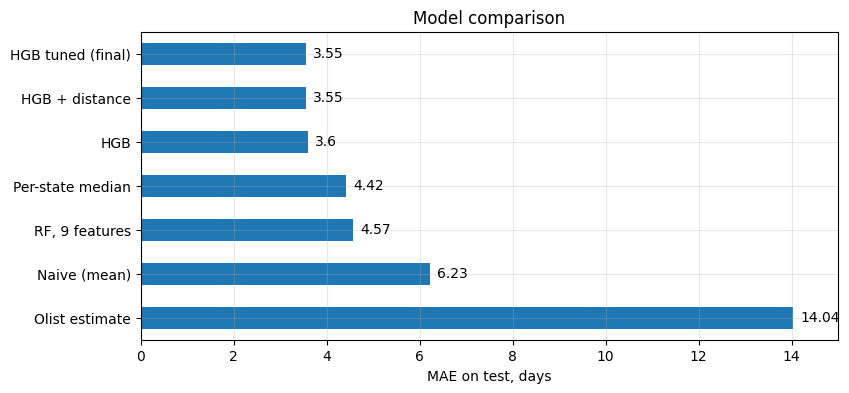

In [32]:
results = pd.Series({
    'Olist estimate': round(mae_olist, 2),
    'Naive (mean)': round(mae_naive, 2),
    'Per-state median': round(mae_state, 2),
    **{name: round(mean_absolute_error(test[TARGET], p), 2) for name, p in preds.items()},
    'HGB tuned (final)': round(mean_absolute_error(test[TARGET], pred_final), 2),
}).sort_values(ascending=False)

ax = results.plot.barh(figsize=(9, 4))
for i, v in enumerate(results):
    ax.text(v + 0.15, i, str(v), va='center')

plt.xlim(0, 15)
plt.xlabel("MAE on test, days")
plt.title("Model comparison")
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

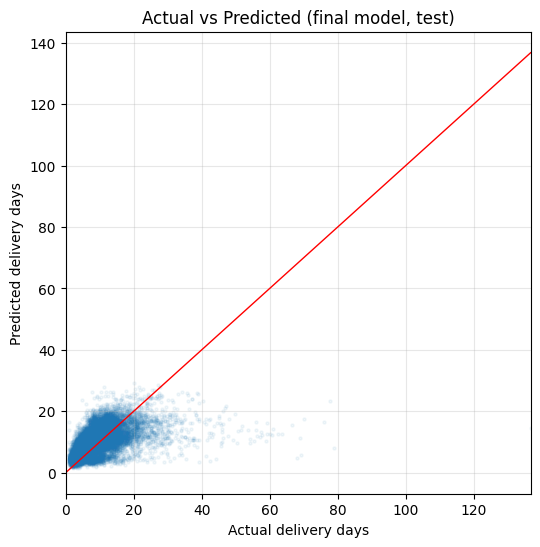

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(test[TARGET], pred_final, alpha=0.06, s=5)
lim = test[TARGET].max()
plt.plot([0, lim], [0, lim], color='red', linewidth=1)
plt.xlim(0, lim)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual vs Predicted (final model, test)")
plt.savefig('../images/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
joblib.dump(final_model, "../models/hgb_final.joblib")
joblib.dump(FEATURES_GEO, "../models/features.joblib")

['../models/features.joblib']

## Summary

Final model: HistGradientBoosting, absolute_error loss, 11 features. MAE 3.55 on test
against 4.42 for a per-state median and 14.04 for Olist's estimate. That is a 20% gain
over the median — real, but modest, and the median is the honest comparison here.

Biggest gain came from matching the loss to the metric: squared_error to absolute_error
moved validation MAE from 5.09 to 4.52. Tuning gave nothing.

Test MAE is below validation MAE, 3.55 vs 4.37, because test falls in the fastest season.
Trimming at 60 days applies to training data only. Test used once.

R2 is 0.23. Rare long delays are not predictable from order-time features.